In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scripts.translation import mapping
from scripts.imputation import infer_alcohol, taste_columns, impute_taste

from unidecode import unidecode
sns.set_theme("notebook", "darkgrid")

%load_ext autoreload
%autoreload 2

# Imputation of missing values

There are several variables to impute :
- alcohol (weighted average)
- taste
- clean grapes

In [2]:
grapes_df = pd.read_csv("db_cleaned/grapes_merged.csv")
parents = pd.read_csv("data_vivino/filt_all_wines_parent.csv")
wines = pd.read_json("db_cleaned/wines_merged3.json")

wines["type"] = wines["type"].replace({"spark":"sparkling", "fortif":"fortified"})
wines = wines[wines["id"] != 142522005 and wines["id"] != 144353810] # distillates

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## Alcohol percentage
Alcohol percentage is inferred by taking weighted average between alcohol percentage of the parent wine and the median of its vintages. The goal is to prioritize vintages if there are lots of them. Hence, values are inferred based on the formula
$$a = (1 - w)\cdot\text{median}_\text{vintages} + w \cdot a_\text{parent}$$
$$w = \dfrac{1}{1 + \text{|vintages with known alcohol|}}$$

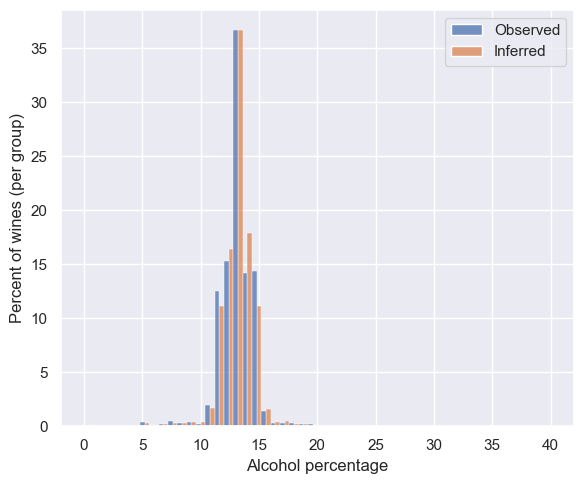

In [ ]:
alcohol_inferred = infer_alcohol(wines, True)

# Plot distribution of observed values / inferred values. Percent is calculated by taking datasets separately
fig = plt.figure(figsize=(6, 5))
ax=sns.histplot(data=alcohol_inferred, x="alcohol", bins=50, hue="inferred", multiple="dodge", stat="percent", common_norm=False, common_bins=True)
ax.legend_.set_title(None)
ax.set_ylabel("Percent of wines (per group)")
ax.set_xlabel("Alcohol percentage")
plt.tight_layout()

fig.savefig("images/imputation/alcohol.pdf", bbox_inches="tight")

# Replace values into dataframe
wines = wines.merge(alcohol_inferred[["id", "alcohol"]], on="id", how="left", suffixes=("", "_new"))
wines["alcohol"] = wines["alcohol_new"]
wines = wines.drop(columns="alcohol_new")

## Taste
Taste is inferred directly from blend (except russian wines), so missing `style_seo_name` implies missing taste. Each blend is determined by a region and type of wine (red, white etc). The grape of the same variety can differ from one region to another because of different
- soil
- climate
- winemaking techniques
- harvesting period
- etc

In [97]:
parents[['style_seo_name', 'style_regional_name', 'style_varietal_name']]

,style_seo_name,style_regional_name,style_varietal_name
0,bordeaux-white,Bordeaux,White
1,washington-state-cabernet-sauvignon,Washington State,Cabernet Sauvignon
2,french-champagne,French,Champagne
3,french-champagne,French,Champagne
4,northern-italy-white,Northern Italy,White
...,...,...,...
26696,brazilian-sparkling,Brazilian,Sparkling
26697,brazilian-sparkling,Brazilian,Sparkling
26698,south-african-bordeaux-blend,South African,Bordeaux Blend
26699,brazilian-merlot,Brazilian,Merlot


In [98]:
# Add blend name to wines
wines = wines.merge(parents[["id", "style_seo_name"]].rename(columns={"id":"id_parent"}), how="left", on="id_parent")

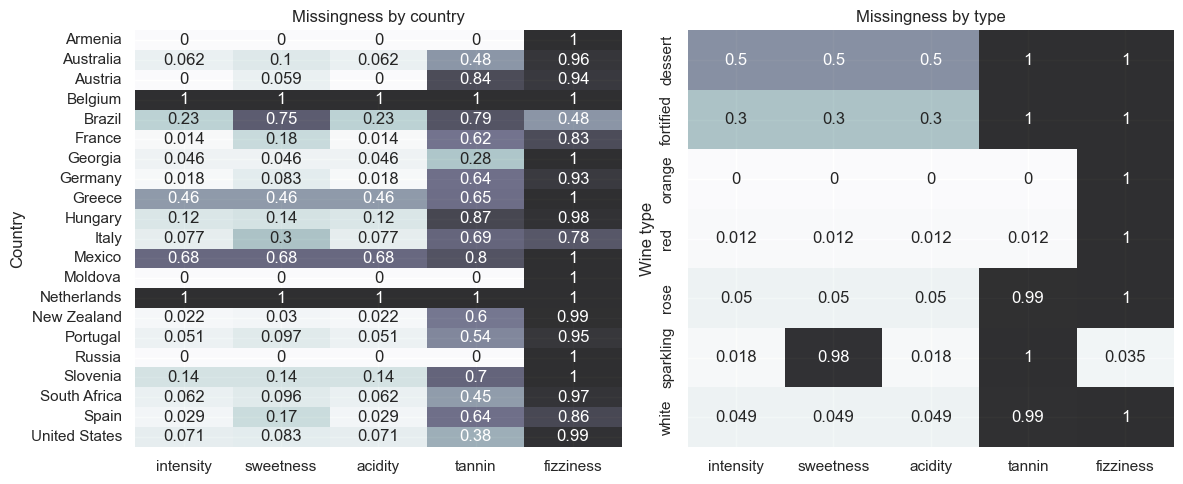

In [99]:
# Missing values per country. 1 = all values are missing, 0 = all values are present
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(wines.groupby("country")[taste_columns].apply(lambda row : row.isnull().sum() / row.shape[0]),
            annot=True, ax=ax1, cmap="bone_r", cbar=False, alpha=0.8)
ax1.set_title("Missingness by country")
ax1.set_ylabel("Country")

sns.heatmap(wines.groupby("type")[taste_columns].apply(lambda x: x.isna().sum() / x.shape[0], include_groups=False),
            annot=True, ax=ax2, cmap="bone_r", cbar=False, alpha=0.8)
ax2.set_title("Missingness by type")
ax2.set_ylabel("Wine type")
plt.tight_layout()
fig.savefig("images/imputation/missingness_country_type.jpg", bbox_inches="tight", dpi=300)

***Conclusion*** 

1. Replace `nan` with `0` : 
- `sweetness` for `spark`
- `tannin` for `rose`, `fortif`, `dessert`, `spark`
- `fizziness` for `white`, `rose`, `red`, `fortif`, `dessert`, `spark`

2. For tastes that cannot be filled easily we can imagine inferring values based on grapes. For each type, take wines that **minimize jaccard distance** and take mean value.

In [100]:
# Filling missing values that are 'undefined' for some types
wines.loc[wines["type"] != "sparkling", "fizziness"] = wines[wines["type"] != "sparkling"]["fizziness"].fillna(0)
wines.loc[~wines["type"].isin(["orange", "red"]), "tannin"] = wines[~wines["type"].isin(["orange", "red"])]["tannin"].fillna(0)
wines.loc[wines["type"] == "sparkling", "sweetness"] = wines[wines["type"] == "sparkling"]["sweetness"].fillna(0)

## Grapes

First of all, all grapes should be translated into English

In [101]:
# Grapes = grapes_vintages union parent_grapes
wines["grapes_merged"] = wines[["grapes", "parent_grapes"]].apply(
    lambda row : list(set(row["grapes"]) | set(row["parent_grapes"]))
    if isinstance(row["grapes"], list) else row, axis=1)

wines_grapes = wines[["id", "grapes_merged"]].explode("grapes_merged")

# Normalizing grapes names (unidecode, lowercase)
grapes_dict = grapes_df.set_index("id")["name"].to_dict() # get id : grape_name dict
wines_grapes["grapes_merged"] = wines_grapes["grapes_merged"].map(grapes_dict).apply(lambda row : unidecode(row).lower() if isinstance(row, str) else row)

# Translate grapes into English and remove some subvarieties
wines_grapes["grapes_merged"] = wines_grapes["grapes_merged"].apply(lambda x : mapping["grapes_translation"].get(x, x))
#wines_grapes["grapes_merged"] = wines_grapes["grapes_merged"].apply(lambda x : mapping["grapes_families"].get(x, x))

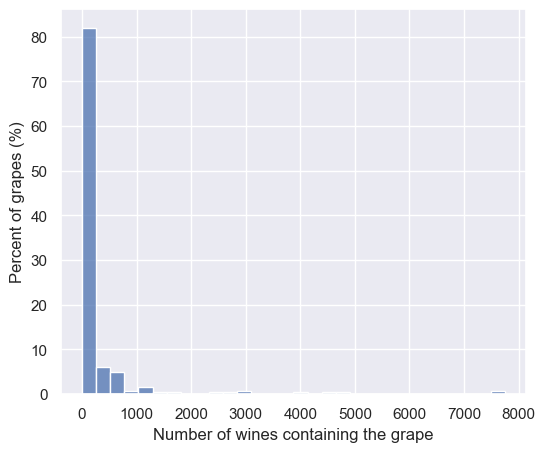

In [102]:
from matplotlib.ticker import MultipleLocator

counts = wines_grapes.groupby("grapes_merged")["id"].nunique()

fig = plt.figure(figsize=(6, 5))
ax=sns.histplot(counts, bins=30, stat="percent")

ax.set_ylabel("Percent of grapes (%)")
ax.set_xlabel("Number of wines containing the grape")

fig.savefig("images/eda/grapes_step1_distr.pdf", bbox_inches="tight")

### Note
We could imagine also taking into account country (just like blends), however when looking at the distribution of means per grape per country of `dessert` or `fortif` no noticeable difference. Moreover, when taking country into account we cant fill even half of missing values

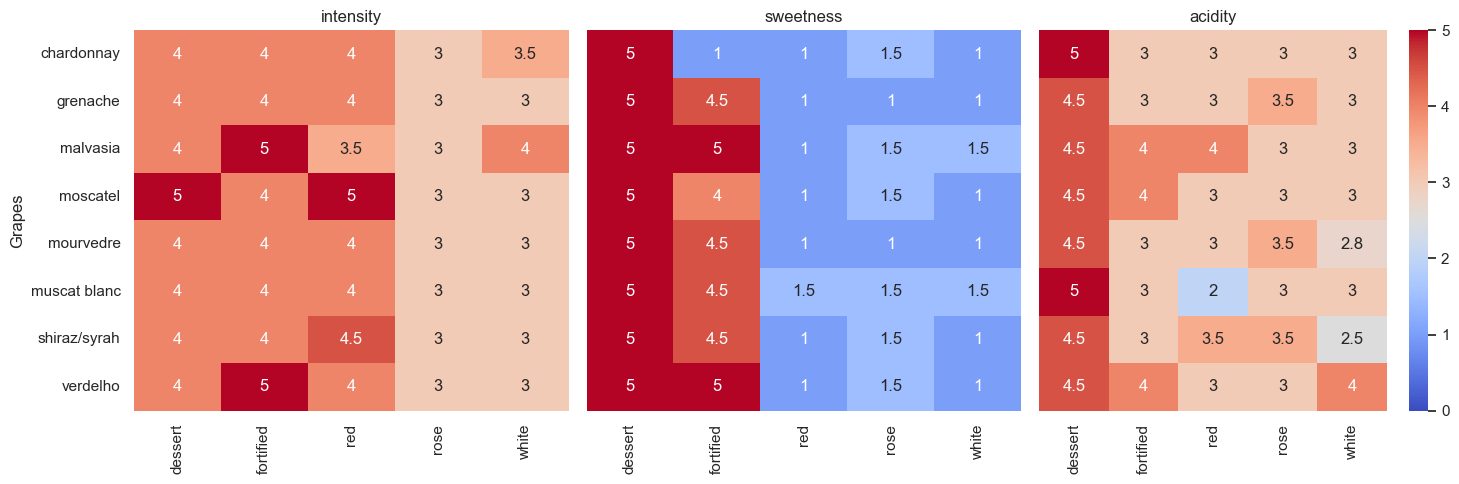

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df = wines.drop(columns=["grapes_merged"]).merge(wines_grapes, how="left", on="id")
df = df[df["type"].isin(["fortified", "dessert", "red", "white", "rose", "white"])]
x_labels=[]
for i, taste in enumerate(["intensity", "sweetness", "acidity"]):
    cbar=False if i < 2 else True
    table = df.pivot_table(index="grapes_merged", columns="type", values=taste, aggfunc="median")
    table = table[~table.isna().any(axis=1)]
    sns.heatmap(table, annot=True, cmap="coolwarm", ax=axes[i], cbar=cbar, vmin=0, vmax=5)
    

    x_labels.append(axes[i].get_yticklabels())
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")
    axes[i].set_title(f"{taste}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)

    if i > 0:
        axes[i].get_yaxis().set_visible(False)
axes[0].set_ylabel("Grapes")
plt.tight_layout()
fig.savefig("images/imputation/taste_type.jpg", bbox_inches="tight", dpi=300)

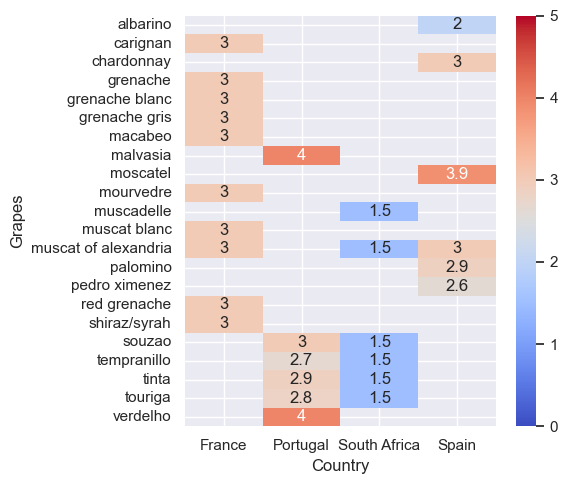

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

df = wines.drop(columns=["grapes_merged"]).merge(wines_grapes, how="left", on="id")
df = df[(df["type"]=="fortified")]
sns.heatmap(df.pivot_table(index="grapes_merged", columns="country", values="acidity", aggfunc="mean"),
            annot=True, cmap="coolwarm", vmin=0, vmax=5)

ax.set_ylabel("Grapes")
ax.set_xlabel("Country")
plt.tight_layout()

fig.savefig("images/imputation/taste_fortified_country.jpg", bbox_inches="tight", dpi=300)
# for i, taste in enumerate(["intensity", "sweetness", "acidity"]):
#     for j, t in enumerate(["fortified", "dessert"]):
#         sns.heatmap(df[df["type"] == t].pivot_table(index="grapes_merged", columns="country", values=taste, aggfunc="mean"),
#                     annot=True, cmap="coolwarm", ax=axes[i, j])

#         axes[i, j].set_title(f"{taste} : {t}")
#         axes[i, j].set_xticklabels(axes[i, j].get_xticklabels(), rotation=90)
# plt.tight_layout()

# fig, axes = plt.subplots(3, 2, figsize=(10, 15))

# df = wines.drop(columns=["grapes_merged"]).merge(wines_grapes, how="left", on="id")

# for i, taste in enumerate(["intensity", "sweetness", "acidity"]):
#     for j, t in enumerate(["fortified", "dessert"]):
#         sns.heatmap(df[df["type"] == t].pivot_table(index="grapes_merged", columns="country", values=taste, aggfunc="mean"),
#                     annot=True, cmap="coolwarm", ax=axes[i, j])

#         axes[i, j].set_title(f"{taste} : {t}")
#         axes[i, j].set_xticklabels(axes[i, j].get_xticklabels(), rotation=90)
# plt.tight_layout()

### KNN-based imputation (Jaccard distance)

In [107]:
wines_grapes = wines_grapes.dropna(subset=["grapes_merged"]).groupby("id")["grapes_merged"].apply(set).reset_index()
wines = wines.drop(columns=["grapes_merged"]).merge(wines_grapes, how="left", on="id")
wines_inferred = impute_taste(wines)

### Comparing rates of missingness

#### Before

Text(0.5, 1.0, 'Missing values by type')

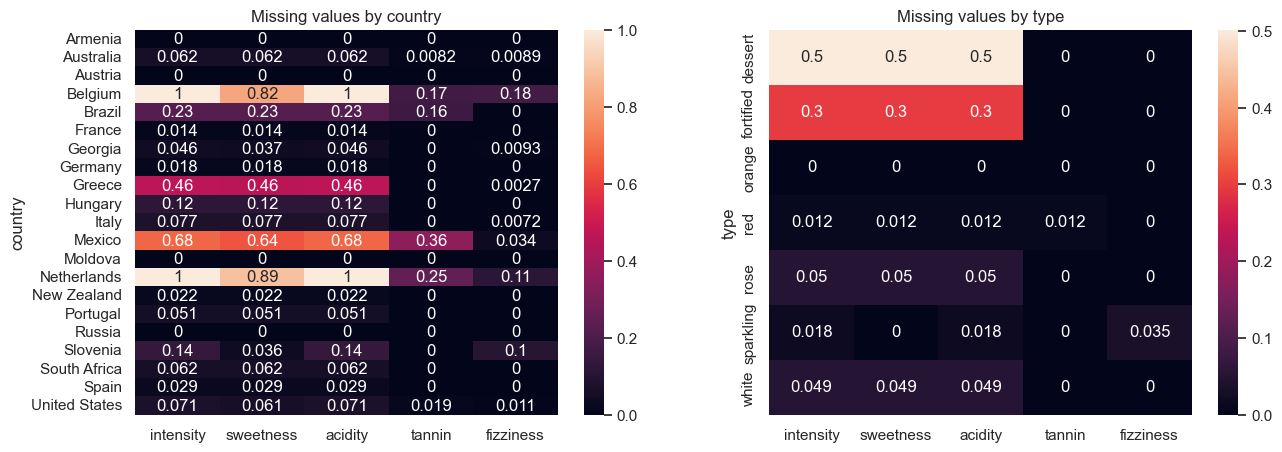

In [108]:
# Missing values per country. 1 = all values are missing, 0 = all values are present
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(wines.groupby("country")[taste_columns].apply(lambda row : row.isnull().sum() / row.shape[0]),
            annot=True, ax=ax1)
ax1.set_title("Missing values by country")

sns.heatmap(wines.groupby("type")[taste_columns].apply(lambda x: x.isna().sum() / x.shape[0], include_groups=False),
            annot=True, ax=ax2)
ax2.set_title("Missing values by type")

#### After

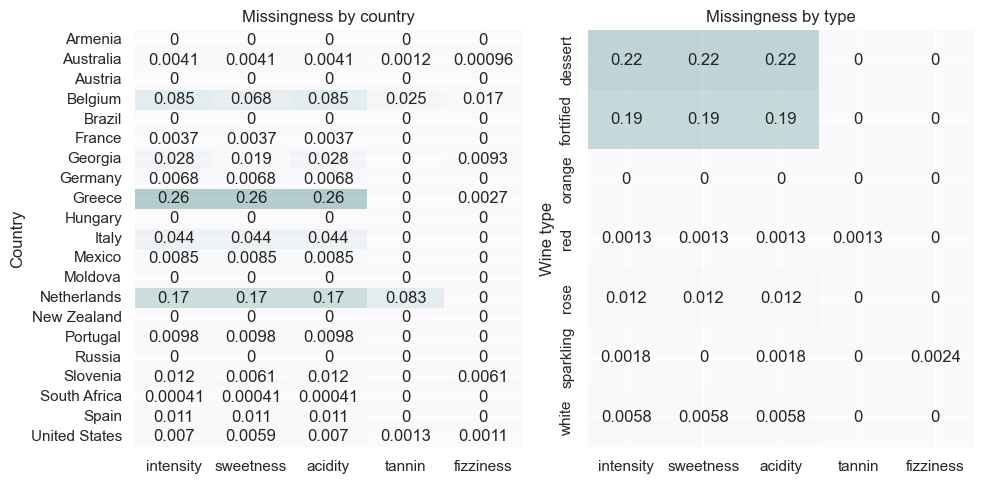

In [ ]:

# Missing values per country. 1 = all values are missing, 0 = all values are present
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(wines_inferred.groupby("country")[taste_columns].apply(lambda row : row.isnull().sum() / row.shape[0]),
            annot=True, ax=ax1, cmap="bone_r", cbar=False, alpha=0.8, vmin=0, vmax=1)
ax1.set_title("Missingness by country")
ax1.set_ylabel("Country")

sns.heatmap(wines_inferred.groupby("type")[taste_columns].apply(lambda x: x.isna().sum() / x.shape[0], include_groups=False),
            annot=True, ax=ax2, cmap="bone_r", cbar=False, alpha=0.8, vmin=0, vmax=1)
ax2.set_title("Missingness by type")
ax2.set_ylabel("Wine type")
plt.tight_layout()
fig.savefig("images/imputation/missingness_country_type_after.jpg", bbox_inches="tight", dpi=300)


### Dropping rows with missing tastes
For some wines, values couldn't be inferred. These rows will be dropped

In [ ]:
mask = wines_inferred[taste_columns + ["alcohol", "price", "year"]].isna().any(axis=1)

total_per_type = wines_inferred.groupby("type").size()
mask_per_type = wines_inferred[mask].groupby("type").size()
print("Percentage of types to drop")
print((mask_per_type / total_per_type).fillna(0))


total_per_country = wines_inferred.groupby("country").size()
mask_per_country = wines_inferred[mask].groupby("country").size()
print("Percentage of countries to drop")
print((mask_per_country / total_per_country).fillna(0))

print(mask.sum())

## Professional ratings

## Drinking window

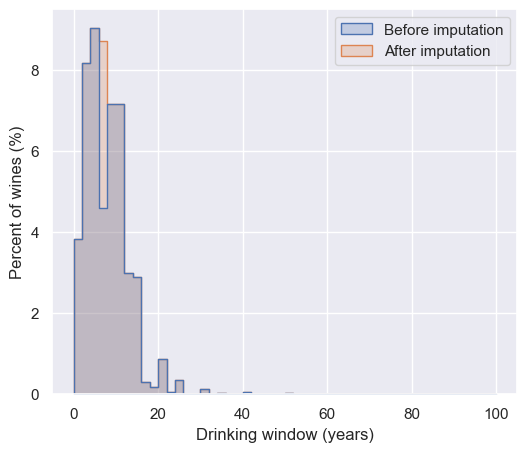

In [110]:
fig=plt.figure(figsize=(6, 5))
diff = wines[["window_end_year", "window_start_year", "price"]].copy()
diff["Observed"] =  wines["window_end_year"] - wines["window_start_year"]

diff["Inferred"] = diff["Observed"]
diff["Inferred"] = diff["Inferred"].fillna(diff["Inferred"].median())
diff = diff.melt(id_vars=["window_end_year", "window_start_year", "price"],
                 value_vars=["Observed", "Inferred"], var_name="Inferred", value_name="Drinking window (years)")

diff["Inferred"] = diff["Inferred"].replace({"Inferred":"After imputation", "Observed":"Before imputation"})

ax=sns.histplot(data=diff, x="Drinking window (years)", hue="Inferred", bins=50, element="step", stat="percent")
ax.set_xlabel("Drinking window (years)")
ax.set_ylabel("Percent of wines (%)")
ax.legend_.set_title(None)
plt.savefig("images/imputation/drinking_window_after.pdf", bbox_inches="tight")